# ARTI406 Assignment 2

Dataset: Sample Superstore Dataset

Student: Sara Alidrissi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("SampleSuperstore.csv")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Task 1: Identify Data Quality Issues

In [2]:
print("Dataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(9994, 13)

Data Types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Missing Values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate Rows:
17


###Explanation

The dataset contains 9,994 rows and 13 columns. A data quality assessment was performed by checking data types, missing values, and duplicate records. No missing values were found in any of the columns, indicating that the dataset is complete. However, 17 duplicate rows were detected, which may introduce redundancy and affect analysis results. Therefore, duplicate records were identified as the main data quality issue in the dataset.

## Task 2: Apply One Missing Value Strategy

In [3]:
df_task2 = df.copy()

# Introduce missing values for demonstration
df_task2.loc[0:9, 'Profit'] = np.nan

print("Missing values before handling:")
print(df_task2['Profit'].isnull().sum())

# Mean Imputation
mean_profit = df_task2['Profit'].mean()
df_task2['Profit'] = df_task2['Profit'].fillna(mean_profit)

print("\nMissing values after handling:")
print(df_task2['Profit'].isnull().sum())

Missing values before handling:
10

Missing values after handling:
0


### Explanation

The original dataset contained no missing values. Therefore, 10 missing values were introduced for demonstration purposes in the Profit column. Mean imputation was applied because Profit is a numerical feature. Then all missing values were successfully handeled.

## Task 3: Detect and Handle Outliers Using IQR

In [4]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]

print("Number of Outliers:", len(outliers))

df_no_outliers = df[(df['Profit'] >= lower_bound) & (df['Profit'] <= upper_bound)]

print("Original Dataset Shape:", df.shape)
print("Dataset Shape After Removing Outliers:", df_no_outliers.shape)

Number of Outliers: 1881
Original Dataset Shape: (9994, 13)
Dataset Shape After Removing Outliers: (8113, 13)


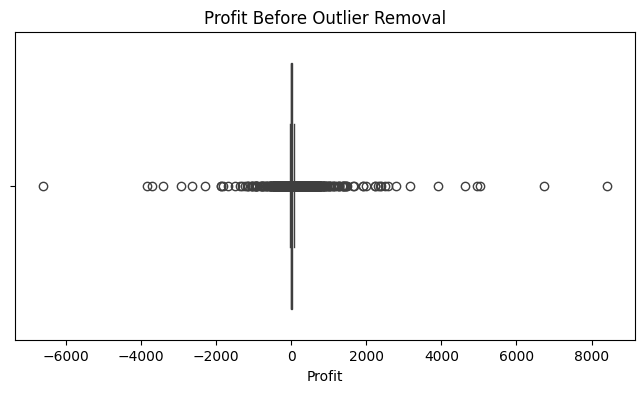

In [5]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Profit'])
plt.title("Profit Before Outlier Removal")
plt.show()

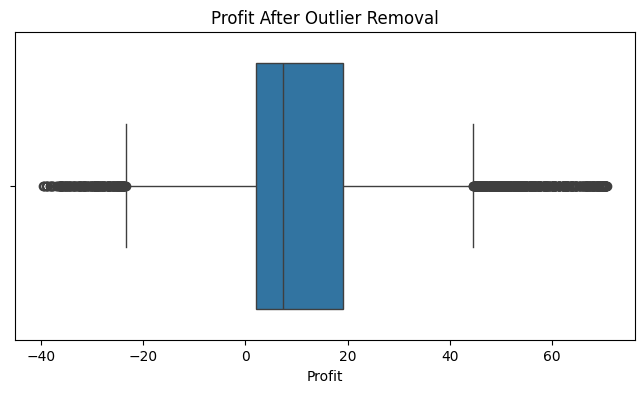

In [6]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_no_outliers['Profit'])
plt.title("Profit After Outlier Removal")
plt.show()

### Explanation

The Interquartile Range (IQR) method was used to identify outliers in the Profit feature. First, the first quartile (Q1) and third quartile (Q3) were calculated, and the IQR was obtained by subtracting Q1 from Q3. Any values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR were considered outliers. Using this method, 1881 outliers were detected and removed. As a result, the dataset size decreased from 9,994 records to 8,113 records. Removing these outliers reduced the influence of extreme values and improved the quality of the data for further analysis.

## Task 4: Normalize Numerical Features Using Min-Max and Z-Score

In [7]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df_no_outliers[['Sales', 'Profit']].copy()

df_minmax[['Sales', 'Profit']] = minmax_scaler.fit_transform(
    df_minmax[['Sales', 'Profit']]
)

print("Min-Max Normalized Data:")
df_minmax.head()

Min-Max Normalized Data:


,Sales,Profit
0,0.093283,0.738957
2,0.005057,0.421428
4,0.007820,0.381966
5,0.017270,0.487558
6,0.002438,0.376975


In [8]:
from sklearn.preprocessing import StandardScaler

zscore_scaler = StandardScaler()

df_zscore = df_no_outliers[['Sales', 'Profit']].copy()

df_zscore[['Sales', 'Profit']] = zscore_scaler.fit_transform(
    df_zscore[['Sales', 'Profit']]
)

print("Z-Score Standardized Data:")
df_zscore.head()

Z-Score Standardized Data:


,Sales,Profit
0,1.094304,1.626023
2,-0.489379,-0.253896
4,-0.439770,-0.487530
5,-0.270145,0.137622
6,-0.536376,-0.517079


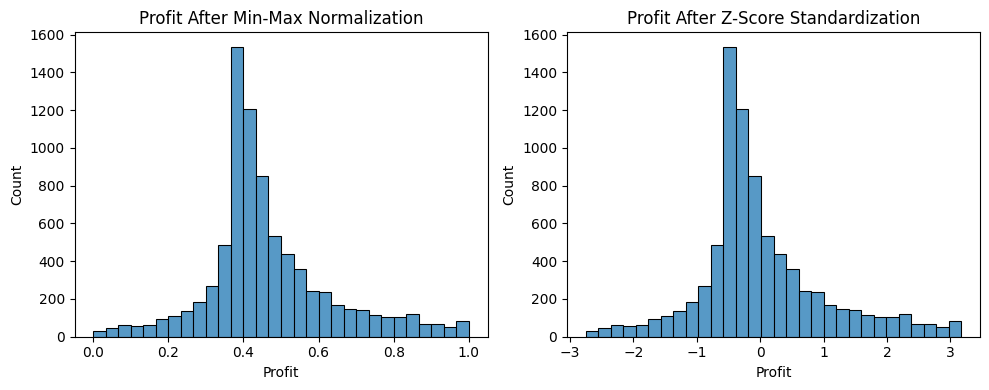

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_minmax['Profit'], bins=30)
plt.title("Profit After Min-Max Normalization")

plt.subplot(1,2,2)
sns.histplot(df_zscore['Profit'], bins=30)
plt.title("Profit After Z-Score Standardization")

plt.tight_layout()
plt.show()

### Explanation

Two normalization techniques were applied to the Sales and Profit features after outlier removal. Min-Max Normalization scaled the values to a range between 0 and 1, making all values comparable regardless of their original scale. Z-Score Standardization transformed the data so that it has a mean of 0 and a standard deviation of 1. The results show that Min-Max normalization produced values within the range [0,1], while Z-Score standardization produced both positive and negative values depending on whether observations were above or below the mean. These techniques help prepare numerical data for machine learning algorithms and dimensionality reduction methods such as PCA.

## Task 5: Apply PCA and Interpret Explained Variance

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_components = pca.fit_transform(df_zscore)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.66115459 0.33884541]


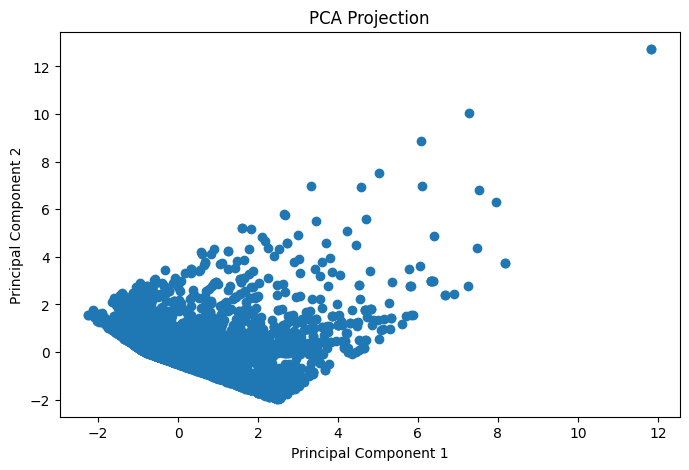

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.show()

###Explanation

The PCA projection shows the data represented in terms of two principal components. The first principal component (PC1) explains 66.12% of the total variance, while the second principal component (PC2) explains 33.88%. The scatter plot indicates that most of the variation in the dataset is captured along PC1, making it the most informative component. Together, PC1 and PC2 account for 100% of the variance, meaning that all information from the selected features is preserved in the transformed data.